In [28]:
#  Importação das Dependências

# Manipulação de dados
import pandas as pd
import numpy as np
import plotly.express as px

# Modelagem tradicional sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, silhouette_score
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# PLN (comentado para ativar quando usar)
#from sklearn.feature_extraction.text import TfidfVectorizer
#from sklearn.naive_bayes import MultinomialNB

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# PySpark para Big Data
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.clustering import KMeans as SparkKMeans

In [29]:
# 📂 Conectar ao Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
# 📥 Carregar Base de Dados
df = pd.read_csv("/content/drive/MyDrive/ANALISE_PI/alunos_com_erros.csv")

In [ ]:
# 📊 Exploração Inicial
print(df.head())
print(df.info())
print(df.isnull().sum())

In [69]:
# ===============================
# 📌 Pré-processamento (Pandas)
# ===============================

# Remover registros com valores nulos e criar cópia
df_model = df.dropna().copy()

# Label Encoding para colunas categóricas (exceto target)
label_encoders = {}
for c in df_model.select_dtypes(include='object').columns:
    if c != 'risco_evasao':
        le = LabelEncoder()
        df_model.loc[:, c] = le.fit_transform(df_model[c].astype(str))
        label_encoders[c] = le

# Separar features e target
X = df_model.drop(columns=['risco_evasao'])
y = df_model['risco_evasao']

# Codificar target
le_y = LabelEncoder()
y_encoded = le_y.fit_transform(y)

# Normalizar features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [71]:
# ===============================
# 📊 Modelo de Classificação (Random Forest)
# ===============================

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Relatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=le_y.classes_.astype(str)))

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1647
           1       1.00      0.63      0.77       196

    accuracy                           0.96      1843
   macro avg       0.98      0.81      0.87      1843
weighted avg       0.96      0.96      0.96      1843



In [70]:
# ===============================
# 📈 Clusterização (KMeans + PCA)
# ===============================

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

print("Silhouette Score:", silhouette_score(X_scaled, clusters))

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='Set2')
plt.title('Clusters dos Alunos (KMeans + PCA)')
plt.show()


Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1647
           1       1.00      0.63      0.77       196

    accuracy                           0.96      1843
   macro avg       0.98      0.81      0.87      1843
weighted avg       0.96      0.96      0.96      1843



In [72]:
# ===============================
# 📉 Regressão Linear
# ===============================

if 'desempenho_1' in df_model.columns:
    X_reg = df_model.drop(columns=['desempenho_1'], errors='ignore')
    y_reg = df_model['desempenho_1']

    X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

    reg = LinearRegression()
    reg.fit(X_train_r, y_train_r)

    y_pred_r = reg.predict(X_test_r)

    print("R²:", r2_score(y_test_r, y_pred_r))
    print("MSE:", mean_squared_error(y_test_r, y_pred_r))

R²: 0.5411348239690859
MSE: 0.3327879583621368


In [36]:
# 📚 PLN (Processamento de Linguagem Natural)
# Verificar existência de coluna 'obs' para análise textual
#if 'obs' in df.columns:
    #df_pln = df.dropna(subset=['obs', 'risco_evasao'])
    #X_text = df_pln['obs'].astype(str)
    #y_text = LabelEncoder().fit_transform(df_pln['risco_evasao'])

    # Vetorização com TF-IDF
   # vectorizer = TfidfVectorizer(stop_words='portuguese')
   # X_vec = vectorizer.fit_transform(X_text)

    # Classificação com Naive Bayes
  #  X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(X_vec, y_text, test_size=0.2, random_state=42)
  # clf_text = MultinomialNB()
 #   clf_text.fit(X_train_text, y_train_text)

#    y_pred_text = clf_text.predict(X_test_text)
  #  print("Relatório PLN:")
 #   print(classification_report(y_test_text, y_pred_text))
#else:
#    print("A coluna 'obs' com texto não foi encontrada.")


A coluna 'obs' com texto não foi encontrada.


In [73]:
# ===============================
# ⚙️ Análise com PySpark
# ===============================

# Iniciar sessão Spark
spark = SparkSession.builder.appName("Modelo_Alunos").master("local[*]").getOrCreate()

In [ ]:
# Carregar dados no Spark
df_spark = spark.read.csv("/content/drive/MyDrive/ANALISE_PI/alunos_com_erros.csv", header=True, inferSchema=True)
df_spark.printSchema()
df_spark.show(5)

In [ ]:
# Indexar variável alvo
indexer = StringIndexer(inputCol="risco_evasao", outputCol="label")
df_indexed = indexer.fit(df_spark).transform(df_spark)

# Definir features numéricas
features = ["idade", "renda_familiar", "notas_1", "faltas_1", "desempenho_1"]

# Converter para double e preencher nulos
for col_name in features:
    df_indexed = df_indexed.withColumn(col_name, col(col_name).cast("double"))
    mean_val = df_indexed.select(col(col_name)).agg({col_name: "mean"}).collect()[0][0]
    fill_val = mean_val if mean_val is not None else 0.0
    df_indexed = df_indexed.na.fill({col_name: fill_val})

# Criar vetor de features
assembler = VectorAssembler(inputCols=features, outputCol="features")
df_final = assembler.transform(df_indexed)

# Separar treino e teste
train_data, test_data = df_final.randomSplit([0.8, 0.2], seed=42)

# Treinar modelo Árvore de Decisão
dt = DecisionTreeClassifier(labelCol="label", featuresCol="features")
model = dt.fit(train_data)

# Previsões e avaliação
predictions = model.transform(test_data)

evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(predictions)
print(f"Acurácia do modelo Spark: {accuracy:.4f}")

# -------------------------------
# Visualizar resultado acurácia
labels = ['Acurácia', 'Erro']
sizes = [accuracy, 1 - accuracy]

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#4CAF50', '#F44336'])
plt.title('Acurácia do Modelo de Evasão')
plt.show()

# Informações adicionais
print("\nInformações do DataFrame Spark:")
print("Colunas disponíveis:", df_spark.columns)
print("Contagem de linhas:", df_spark.count())
for coluna in features:
    print(f"Tipo da coluna {coluna}:", df_spark.schema[coluna].dataType)
    print(f"Valores únicos na coluna {coluna}:", df_spark.select(coluna).distinct().count())




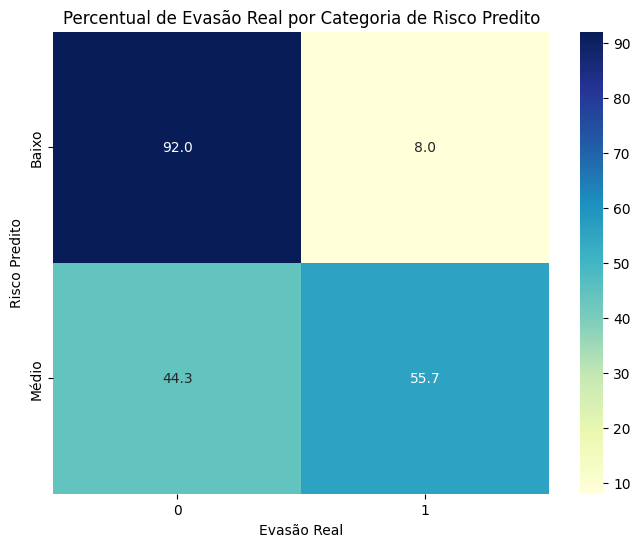

In [84]:
# Tabela cruzada risco predito x real (percentual)
if 'risco_predito' in df_model.columns:
    ct = pd.crosstab(df_model['risco_predito'], df_model['risco_evasao'], normalize='index') * 100
    plt.figure(figsize=(8,6))
    sns.heatmap(ct, annot=True, fmt=".1f", cmap="YlGnBu")
    plt.title("Percentual de Evasão Real por Categoria de Risco Predito")
    plt.ylabel("Risco Predito")
    plt.xlabel("Evasão Real")
    plt.show()

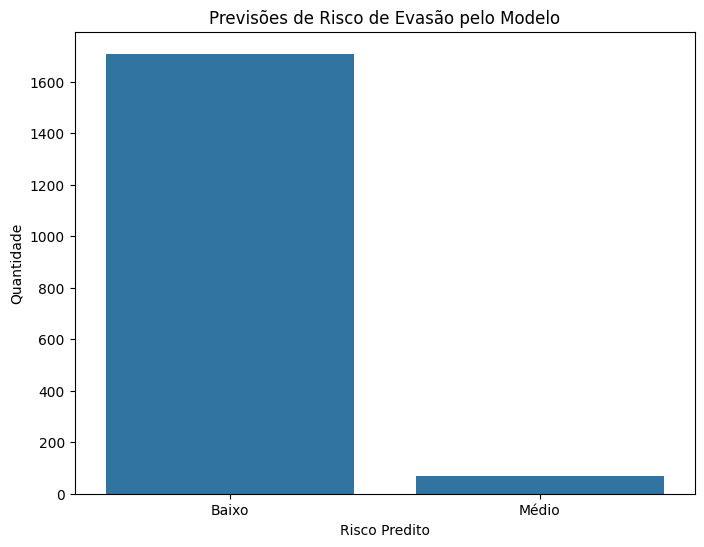

In [86]:
# Distribuição risco predito pelo modelo
plt.figure(figsize=(8,6))
sns.countplot(x='risco_predito', data=df_model)
plt.title('Previsões de Risco de Evasão pelo Modelo')
plt.xlabel('Risco Predito')
plt.ylabel('Quantidade')
plt.show()

Colunas após merge: Index(['aluno_id', 'nome_aluno', 'email_aluno', 'curso', 'status', 'turma',
       'sexo', 'idade', 'trabalha', 'renda_familiar', 'acompanhamento_medico',
       'tem_filho', 'estado_civil', 'semestre', 'bimestre', 'aula_1',
       'professor_1', 'notas_1', 'faltas_1', 'desempenho_1', 'aula_2',
       'professor_2', 'notas_2', 'faltas_2', 'desempenho_2', 'aula_3',
       'professor_3', 'notas_3', 'faltas_3', 'desempenho_3', 'aula_4',
       'professor_4', 'notas_4', 'faltas_4', 'desempenho_4', 'aula_5',
       'professor_5', 'notas_5', 'faltas_5', 'desempenho_5', 'risco_evasao',
       'risco_predito'],
      dtype='object')
  aluno_id nome_aluno email_aluno curso status turma sexo  idade  trabalha  \
0        3       7088        6203    25      2     0    3    3.0         0   
1        9       3263        6243    30      1     0    3   27.0         0   
2       14       1011         364    45      1     0    3   26.0         0   
3       20       2965        7326  

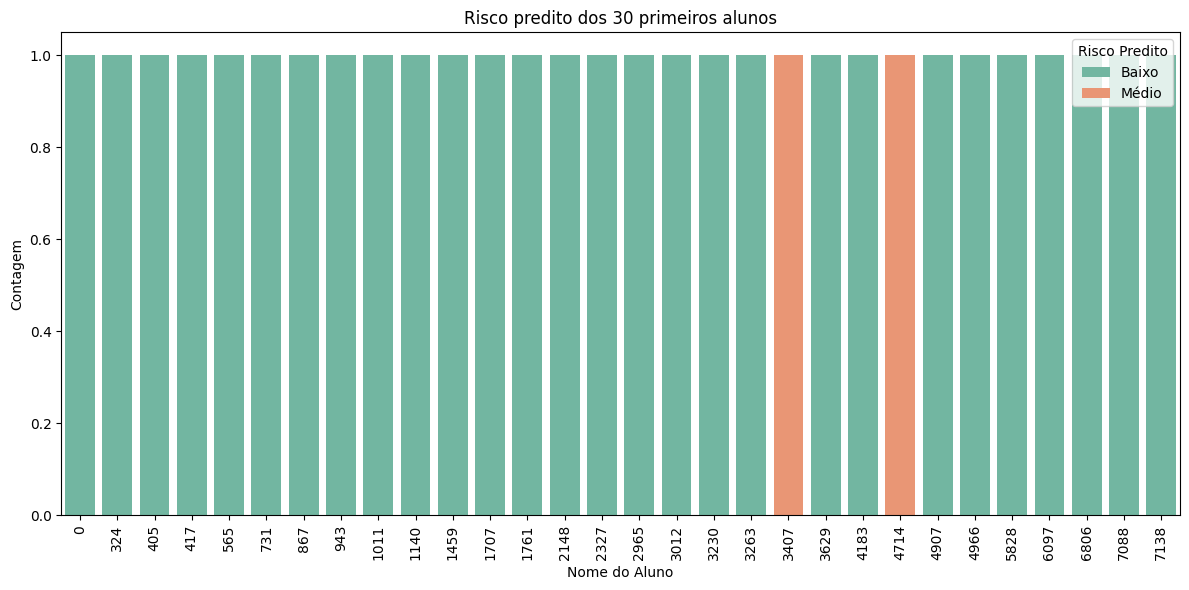

In [89]:

# ===============================
# 📋 Previsões Spark para análise detalhada
# ===============================

# Mapear as classes numéricas para texto (exemplo)
map_labels = {0: "Baixo", 1: "Médio", 2: "Alto"}

# Converter previsões Spark para Pandas
predictions_pandas = predictions.select("aluno_id", "prediction").toPandas()
predictions_pandas['risco_predito'] = predictions_pandas['prediction'].map(map_labels)

# Ajustar tipos para merge
df_model['aluno_id'] = df_model['aluno_id'].astype(str)
predictions_pandas['aluno_id'] = predictions_pandas['aluno_id'].astype(str)

# Remover coluna risco_predito anterior para evitar conflito
if 'risco_predito' in df_model.columns:
    df_model = df_model.drop(columns=['risco_predito'])

# Merge das previsões Spark no df_model
df_model = df_model.merge(predictions_pandas[['aluno_id', 'risco_predito']], on='aluno_id', how='inner')

print("Colunas após merge:", df_model.columns)
print(df_model.head())

# Filtrar alunos de alto risco
alunos_alto_risco = df_model[df_model['risco_predito'] == 'Alto']
print(alunos_alto_risco[['nome_aluno', 'desempenho_1', 'faltas_1', 'notas_1']].head())

# Gráfico dos 30 primeiros alunos e seu risco predito
plt.figure(figsize=(12,6))
sns.countplot(data=df_model.head(30), x='nome_aluno', hue='risco_predito', palette='Set2')
plt.xticks(rotation=90)
plt.title("Risco predito dos 30 primeiros alunos")
plt.xlabel("Nome do Aluno")
plt.ylabel("Contagem")
plt.legend(title='Risco Predito')
plt.tight_layout()
plt.show()

<ipython-input-90-daa9aa89be99>:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




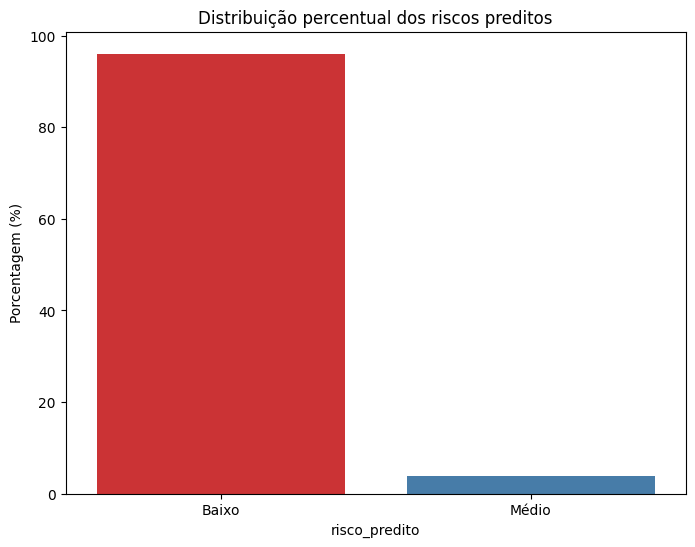

In [90]:

# Gráfico percentual dos riscos preditos
plt.figure(figsize=(8,6))
risco_counts = df_model['risco_predito'].value_counts(normalize=True) * 100
sns.barplot(x=risco_counts.index, y=risco_counts.values, palette='Set1')
plt.ylabel("Porcentagem (%)")
plt.title("Distribuição percentual dos riscos preditos")
plt.show()

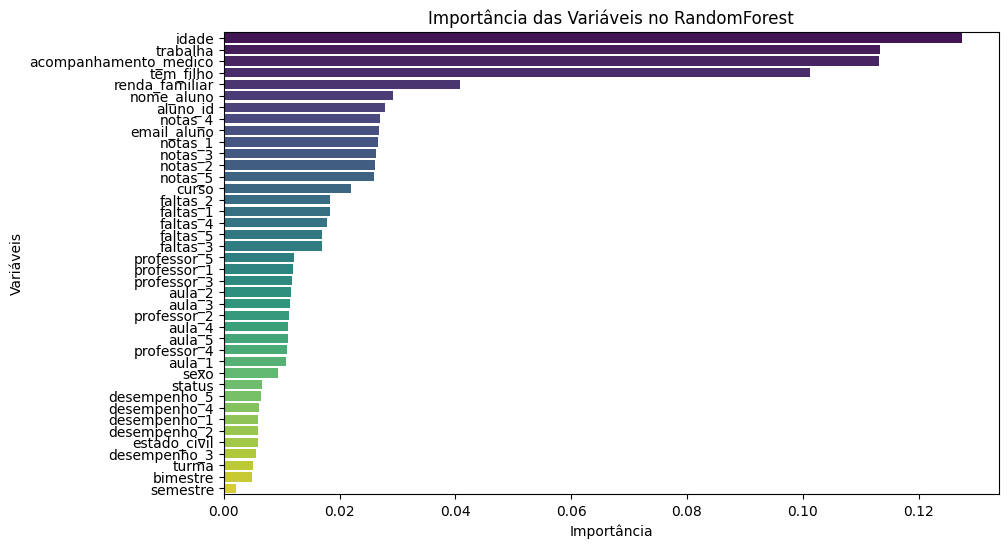

In [91]:
# Criar dataframe para o gráfico

df_imp = pd.DataFrame({
    'Variável': features_names[indices],
    'Importância': importances[indices]
})

plt.figure(figsize=(10,6))
sns.barplot(data=df_imp, x='Importância', y='Variável', hue='Variável', dodge=False, legend=False, palette="viridis")
plt.title('Importância das Variáveis no RandomForest')
plt.xlabel('Importância')
plt.ylabel('Variáveis')
plt.show()


In [92]:
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = clusters
df_pca['Risco_Predito'] = df_model['risco_predito']

fig = px.scatter(df_pca, x='PC1', y='PC2', color='Risco_Predito',
                 title='Alunos por Risco de Evasão (PCA + RandomForest)',
                 labels={'PC1':'Componente Principal 1', 'PC2':'Componente Principal 2'})
fig.show()


In [81]:
# ===============================
# 📊 PCA + RandomForest: Visualização interativa
# ===============================

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = clusters
df_pca['Risco_Predito'] = df_model['risco_predito']

fig = px.scatter(
    df_pca, x='PC1', y='PC2', color='Risco_Predito',
    title='Alunos por Risco de Evasão (PCA + RandomForest)',
    labels={'PC1':'Componente Principal 1', 'PC2':'Componente Principal 2'}
)
fig.show()

In [93]:
# --- Exemplo: definir motivo de evasão com base em regras simples ---
# Se tiver a coluna 'motivo_evasao' use ela, senão a gente simula baseada nas variáveis
def definir_motivo(row):
    if row['faltas_1'] > 10:
        return 'Faltas Excessivas'
    elif row['desempenho_1'] < 5:
        return 'Baixo Desempenho'
    elif row['renda_familiar'] < 1500:
        return 'Baixa Renda'
    else:
        return 'Outro'

# Criar coluna de motivo (caso não exista)
if 'motivo_evasao' not in df_model.columns:
    df_model['motivo_evasao'] = df_model.apply(definir_motivo, axis=1)

# --- Contagem dos motivos por risco predito ---
df_motivos = df_model.groupby(['risco_predito', 'motivo_evasao']).size().reset_index(name='quantidade')

# --- Gráfico interativo com Plotly ---
fig = px.bar(
    df_motivos,
    x='motivo_evasao',
    y='quantidade',
    color='risco_predito',
    barmode='group',
    text='quantidade',
    title='Distribuição dos Motivos de Evasão por Categoria de Risco',
    labels={'motivo_evasao': 'Motivo de Evasão', 'quantidade': 'Número de Alunos'}
)

fig.update_layout(
    xaxis_title='Motivo de Evasão',
    yaxis_title='Número de Alunos',
    legend_title='Risco Predito',
    bargap=0.3
)

fig.show()